In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


DYN = ROOT / "indexes" / "wolverine_exp"



new_file = DYN / "dapg_wolverine_graphstats_b10000_sift_k100_rounds5_T24_efC80_L2_K18_fi900000_fb10000_updrandom_new_vardefault_ef2100.csv"


print("New file exists:", new_file.exists(), new_file.name)


new_df = pd.read_csv(new_file)


new_df["run"] = "New graph-stats result"


print("New columns:", new_df.columns.tolist())


display(new_df.head())

New file exists: True dapg_wolverine_graphstats_b10000_sift_k100_rounds5_T24_efC80_L2_K18_fi900000_fb10000_updrandom_new_vardefault_ef2100.csv
New columns: ['round', 'recall', 'search_OPS', 'delete_OPS', 'insert_OPS', 'search_ms', 'delete_s', 'insert_s', 'post_active_nodes', 'post_live_edges', 'post_avg_live_degree', 'post_min_live_degree', 'post_max_live_degree', 'post_zero_live_degree_nodes', 'post_stale_edges', 'run']


,round,recall,search_OPS,delete_OPS,insert_OPS,search_ms,delete_s,insert_s,post_active_nodes,post_live_edges,post_avg_live_degree,post_min_live_degree,post_max_live_degree,post_zero_live_degree_nodes,post_stale_edges,run
0,0,0.9771,179.244,19775.4,2172.64,5.57899,0.505679,4.60269,900000,28208518,31.3428,0,48,1,92821,New graph-stats result
1,1,0.9771,181.570,23091.8,1857.33,5.50753,0.433054,5.38408,900000,25221370,28.0237,0,48,10,172384,New graph-stats result
2,2,0.9769,177.674,27535.2,1988.31,5.62829,0.363172,5.02940,900000,23139183,25.7102,0,48,73,240620,New graph-stats result
3,3,0.9762,186.334,31911.9,2018.46,5.36672,0.313363,4.95428,900000,21552881,23.9476,0,48,249,299888,New graph-stats result
4,4,0.9754,193.736,35124.9,2270.39,5.16166,0.284698,4.40453,900000,20288538,22.5428,0,48,507,351126,New graph-stats result


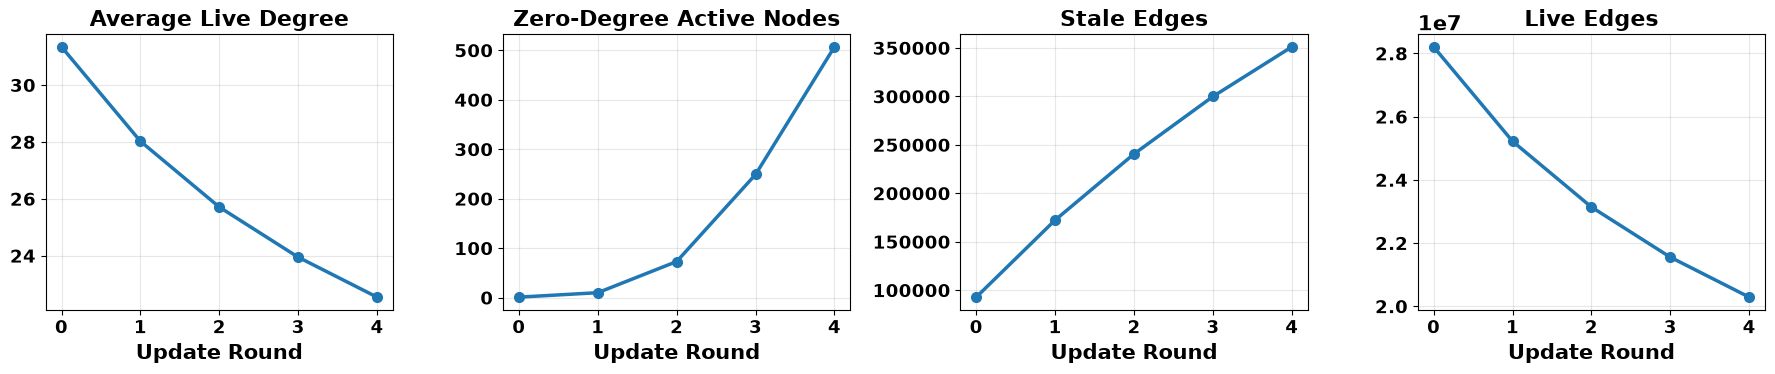

In [2]:
graph_cols = [
    ("post_avg_live_degree", "Average Live Degree"),
    ("post_zero_live_degree_nodes", "Zero-Degree Active Nodes"),
    ("post_stale_edges", "Stale Edges"),
    ("post_live_edges", "Live Edges"),
]

missing = [c for c, _ in graph_cols if c not in new_df.columns]

if missing:
    print("Missing graph-stat columns. You probably loaded an old CSV:", missing)

else:
    # Global font settings
    plt.rcParams.update({
        "font.size": 15,
        "font.weight": "bold",
        "axes.labelweight": "bold",
        "axes.titleweight": "bold",
    })

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for ax, (col, title) in zip(axes, graph_cols):
        ax.plot(
            new_df["round"],
            new_df[col],
            marker="o",
            linewidth=2.5,
            markersize=7
        )

        ax.set_title(title, fontsize=16, fontweight="bold")
        ax.set_xlabel("Update Round", fontsize=15, fontweight="bold")

        
        ax.tick_params(axis="both", labelsize=13)

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        "dapg_dynamic_graph_stats.pdf",
        bbox_inches="tight"
    )

    plt.show()